In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Neural Collaborative Filtering for Personalized Ranking

This section moves beyond explicit feedback, introducing the neural collaborative filtering (NCF) framework for recommendation with implicit feedback. Implicit feedback is pervasive in recommender systems. Actions such as clicks, buys, and watches are common implicit feedback which are easy to collect and indicative of users' preferences. The model we will introduce, titled NeuMF [@He.Liao.Zhang.ea.2017], short for neural matrix factorization, aims to address the personalized ranking task with implicit feedback. This model leverages the flexibility and non-linearity of neural networks to replace dot products of matrix factorization, aiming at enhancing the model expressiveness. In specific, this model is structured with two subnetworks including generalized matrix factorization (GMF) and MLP and models the interactions from two pathways instead of simple dot products. The outputs of these two networks are concatenated for the final prediction scores calculation. Unlike the rating prediction task in AutoRec, this model generates a ranked recommendation list to each user based on the implicit feedback. We will use the personalized ranking loss introduced in the last section to train this model.

## The NeuMF model

As aforementioned, NeuMF fuses two subnetworks. The GMF is a generic neural network version of matrix factorization where the input is the elementwise product of user and item latent factors. It consists of two neural layers:

$$
\mathbf{x} = \mathbf{p}_u \odot \mathbf{q}_i \\
\hat{y}_{ui} = \alpha(\mathbf{h}^\top \mathbf{x}),
$$

where $\odot$ denotes the Hadamard product of vectors. $\mathbf{P} \in \mathbb{R}^{m \times k}$  and $\mathbf{Q} \in \mathbb{R}^{n \times k}$ correspond to user and item latent matrix respectively. $\mathbf{p}_u \in \mathbb{R}^{ k}$ is the $u^\textrm{th}$ row of $P$ and $\mathbf{q}_i \in \mathbb{R}^{ k}$ is the $i^\textrm{th}$ row of $Q$.  $\alpha$ and $\mathbf{h}$ denote the activation function and weight of the output layer. $\hat{y}_{ui}$ is the prediction score of the user $u$ might give to the item $i$.

Another component of this model is MLP. To enrich model flexibility, the MLP subnetwork does not share user and item embeddings with GMF. It uses the concatenation of user and item embeddings as input. With the complicated connections and nonlinear transformations, it is capable of estimating the intricate interactions between users and items. More precisely, the MLP subnetwork is defined as:

$$
\begin{aligned}
z^{(1)} &= \phi_1(\mathbf{U}_u, \mathbf{V}_i) = \left[ \mathbf{U}_u, \mathbf{V}_i \right] \\
\phi^{(2)}(z^{(1)})  &= \alpha^1(\mathbf{W}^{(2)} z^{(1)} + b^{(2)}) \\
&... \\
\phi^{(L)}(z^{(L-1)}) &= \alpha^L(\mathbf{W}^{(L)} z^{(L-1)} + b^{(L)}) \\
\hat{y}_{ui} &= \alpha(\mathbf{h}^\top\phi^L(z^{(L-1)}))
\end{aligned}
$$

where $\mathbf{W}^*, \mathbf{b}^*$ and $\alpha^*$ denote the weight matrix, bias vector, and activation function. $\phi^*$ denotes the function of the corresponding layer. $\mathbf{z}^*$ denotes the output of corresponding layer.

To fuse the results of GMF and MLP, instead of simple addition, NeuMF concatenates the second last layers of two subnetworks to create a feature vector which can be passed to the further layers. Afterwards, the outputs are projected with matrix $\mathbf{h}$ and a sigmoid activation function. The prediction layer is formulated as:
$$
\hat{y}_{ui} = \sigma(\mathbf{h}^\top[\mathbf{x}, \phi^L(z^{(L-1)})]).
$$

The following figure illustrates the model architecture of NeuMF.

![Illustration of the NeuMF model](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/rec-neumf.svg)

In [1]:
from d2l import torch as d2l
import torch
from torch import nn
import random

## Model Implementation
The following code implements the NeuMF model. It consists of a generalized matrix factorization model and an MLP with different user and item embedding vectors. The structure of the MLP is controlled with the parameter `nums_hiddens`. ReLU is used as the default activation function.

In [2]:
class NeuMF(nn.Module):
    def __init__(self, num_factors, num_users, num_items, nums_hiddens):
        super().__init__()
        self.P = nn.Embedding(num_users, num_factors)
        self.Q = nn.Embedding(num_items, num_factors)
        self.U = nn.Embedding(num_users, num_factors)
        self.V = nn.Embedding(num_items, num_factors)
        mlp_layers = []
        input_size = num_factors * 2
        for num_hiddens in nums_hiddens:
            mlp_layers.append(nn.Linear(input_size, num_hiddens))
            mlp_layers.append(nn.ReLU())
            input_size = num_hiddens
        self.mlp = nn.Sequential(*mlp_layers)
        # Output raw logits; BPRLoss applies sigmoid internally, so adding
        # a sigmoid here would compose with it and squash gradients.
        self.prediction_layer = nn.Linear(num_factors + nums_hiddens[-1], 1,
                                          bias=False)

    def forward(self, user_id, item_id):
        p_mf = self.P(user_id)
        q_mf = self.Q(item_id)
        gmf = p_mf * q_mf
        p_mlp = self.U(user_id)
        q_mlp = self.V(item_id)
        mlp = self.mlp(torch.cat([p_mlp, q_mlp], dim=1))
        con_res = torch.cat([gmf, mlp], dim=1)
        return self.prediction_layer(con_res)

## Customized Dataset with Negative Sampling

For pairwise ranking loss, an important step is negative sampling. For each user, the items that a user has not interacted with form the pool of negative items. The following function takes user identities and the per-user set of *observed* items (the `candidates` argument, holding items each user has interacted with) and samples a random negative item for each user by drawing from the complement — items not in that user's observed set. During training, the model learns to rank observed positive items above sampled items that were not observed for that user.

In [3]:
class PRDataset(torch.utils.data.Dataset):
    def __init__(self, users, items, candidates, num_items, test_items=None):
        self.users = users
        self.items = items
        # Precompute each user's negative pool once: items the user has not
        # interacted with in train AND not held out as a test positive
        # (excluding test positives prevents leakage into the BPR loss).
        all_items = set(range(num_items))
        test_items = test_items or {}
        self.neg_pool = {
            u: list(all_items - set(candidates.get(u, [])) - set(test_items.get(u, [])))
            for u in candidates}

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        neg_items = self.neg_pool[int(self.users[idx])]
        indices = random.randint(0, len(neg_items) - 1)
        return self.users[idx], self.items[idx], neg_items[indices]

## Evaluator
In this section, we adopt the splitting by time strategy to construct the training and test sets. Two evaluation measures including hit rate at given cutting off $\ell$ ($\textrm{Hit}@\ell$) and area under the ROC curve (AUC) are used to assess the model effectiveness.  Hit rate at given position $\ell$ for each user indicates that whether the recommended item is included in the top $\ell$ ranked list. The formal definition is as follows:

$$
\textrm{Hit}@\ell = \frac{1}{m} \sum_{u \in \mathcal{U}} \textbf{1}(rank_{u, g_u} <= \ell),
$$

where $\textbf{1}$ denotes an indicator function that is equal to one if the ground truth item is ranked in the top $\ell$ list, otherwise it is equal to zero. $rank_{u, g_u}$ denotes the ranking of the ground truth item $g_u$ of the user $u$ in the recommendation list (The ideal ranking is 1). $m$ is the number of users. $\mathcal{U}$ is the user set.

The definition of AUC is as follows:

$$
\textrm{AUC} = \frac{1}{m} \sum_{u \in \mathcal{U}} \frac{1}{|\mathcal{I} \backslash S_u|} \sum_{j \in \mathcal{I} \backslash S_u} \textbf{1}(rank_{u, g_u} < rank_{u, j}),
$$

where $\mathcal{I}$ is the item set and $S_u$ is the set of items user $u$ has already interacted with, so $\mathcal{I} \setminus S_u$ denotes the user's unobserved items that are ranked at evaluation time. Note that many other evaluation protocols such as precision, recall and normalized discounted cumulative gain (NDCG) can also be used.

The following function calculates the hit counts and AUC for each user.

In [4]:

def hit_and_auc(rankedlist, test_matrix, k):
    hits_k = [(idx, val) for idx, val in enumerate(rankedlist[:k])
              if val in set(test_matrix)]
    hits_all = [(idx, val) for idx, val in enumerate(rankedlist)
                if val in set(test_matrix)]
    max = len(rankedlist) - 1
    auc = 1.0 * (max - hits_all[0][0]) / max if len(hits_all) > 0 else 0
    return len(hits_k), auc

Then, the overall Hit rate and AUC are calculated as follows. Note that `evaluate_ranking` rebuilds and `sorted`-ranks each user's candidate scores in a per-user Python loop for clarity; the efficient form would score all users in a batch and select the top items with a single top-k call (PyTorch's `torch.topk`).

In [5]:

def evaluate_ranking(net, test_input, seq, candidates, num_users, num_items,
                     devices):
    ranked_list, ranked_items, hit_rate, auc = {}, {}, [], []
    all_items = set([i for i in range(num_items)])
    for u in range(num_users):
        neg_items = list(all_items - set(candidates[int(u)]))
        user_ids, item_ids, scores = [], [], []
        [item_ids.append(i) for i in neg_items]
        [user_ids.append(u) for _ in neg_items]
        x = [torch.tensor(user_ids)]
        if seq is not None:
            x.append(seq[user_ids, :])
        x.extend([torch.tensor(item_ids)])
        test_data_iter = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(*x), shuffle=False,
            batch_size=1024)
        for values in test_data_iter:
            values = [v.to(devices[0]) for v in values]
            # `net` returns a 1-D tensor of logits per batch; ravel
            # ensures we always extend with scalars regardless of whether
            # the model emits shape (B,) or (B, 1).
            scores.extend(net(*values).detach().cpu().numpy().ravel().tolist())
        item_scores = list(zip(item_ids, scores))
        ranked_list[u] = sorted(item_scores, key=lambda t: t[1], reverse=True)
        ranked_items[u] = [r[0] for r in ranked_list[u]]
        temp = hit_and_auc(ranked_items[u], test_input[u], 50)
        hit_rate.append(temp[0])
        auc.append(temp[1])
    return sum(hit_rate) / len(hit_rate), sum(auc) / len(auc)

## Training and Evaluating the Model

The training function is defined below. We train the model in the pairwise manner.

In [6]:

def train_ranking(net, train_iter, test_iter, loss, optimizer, test_seq_iter,
                  num_users, num_items, num_epochs, devices, evaluator,
                  candidates, eval_step=1):
    timer, hit_rate, auc = d2l.Timer(), 0, 0
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                            legend=['test hit rate', 'test AUC'])
    for epoch in range(num_epochs):
        metric = d2l.Accumulator(3)
        for i, values in enumerate(train_iter):
            input_data = [v.to(devices[0]) for v in values]
            p_pos = net(*input_data[:-1])
            p_neg = net(*input_data[:-2], input_data[-1])
            ls = loss(p_pos, p_neg)
            optimizer.zero_grad()
            ls.backward()
            optimizer.step()
            # Per-batch loss only; accumulating across batches inside `l`
            # turned the printed train-loss into a quadratic sum.
            metric.add(ls.item(), values[0].shape[0], values[0].numel())
            timer.stop()
        with torch.no_grad():
            if (epoch + 1) % eval_step == 0:
                hit_rate, auc = evaluator(net, test_iter, test_seq_iter,
                                          candidates, num_users, num_items,
                                          devices)
                animator.add(epoch + 1, (hit_rate, auc))
    print(f'train loss {metric[0] / metric[1]:.3f}, '
          f'test hit rate {float(hit_rate):.3f}, test AUC {float(auc):.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(devices)}')

Now, we can load the MovieLens 100k dataset and train the model. Since there are only ratings in the MovieLens dataset, with some losses of accuracy, we binarize these ratings to zeros and ones. If a user rated an item, we consider the implicit feedback as one, otherwise as zero. The action of rating an item can be treated as a form of providing implicit feedback.  Here, we split the dataset in the `seq-aware` mode where users' latest interacted items are left out for test.

In [7]:
batch_size = 1024
df, num_users, num_items = d2l.read_data_ml100k()
train_data, test_data = d2l.split_data_ml100k(df, num_users, num_items,
                                              'seq-aware')
users_train, items_train, ratings_train, candidates = d2l.load_data_ml100k(
    train_data, num_users, num_items, feedback="implicit")
users_test, items_test, ratings_test, test_iter = d2l.load_data_ml100k(
    test_data, num_users, num_items, feedback="implicit")
train_iter = torch.utils.data.DataLoader(
    PRDataset(users_train, items_train, candidates, num_items,
              test_items=test_iter), batch_size,
    True, num_workers=d2l.get_dataloader_workers())

We then create and initialize the model. We use a three-layer MLP with constant hidden size 10.

In [8]:
devices = d2l.try_all_gpus()
net = NeuMF(10, num_users, num_items, nums_hiddens=[10, 10, 10])
def init_weights(m):
    if type(m) == nn.Linear or type(m) == nn.Embedding:
        nn.init.normal_(m.weight, std=0.01)
net.apply(init_weights)
net = net.to(devices[0])

The following code trains the model.

train loss 0.154, test hit rate 0.363, test AUC 0.880
14.8 examples/sec on [device(type='cuda', index=0)]


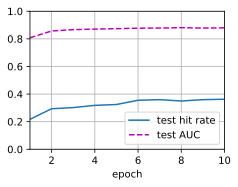

In [9]:
lr, num_epochs, wd = 0.01, 10, 1e-5
loss = d2l.BPRLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=wd)
train_ranking(net, train_iter, test_iter, loss, optimizer, None, num_users,
              num_items, num_epochs, devices, evaluate_ranking, candidates)

## Summary

* Adding nonlinearity to matrix factorization model is beneficial for improving the model capability and effectiveness.
* NeuMF is a combination of matrix factorization and an MLP. The MLP takes the concatenation of user and item embeddings as input.

## Exercises

* Vary the size of latent factors. How does the size of latent factors impact the model performance?
* Vary the architectures (e.g., number of layers, number of neurons of each layer) of the MLP to check its impact on the performance.
* Try different optimizers, learning rate and weight decay rate.
* Try to use hinge loss defined in the last section to optimize this model.

[Discussions](https://d2l.discourse.group/t/403)